## Unidades canónicas
En este notebook se utilizan las siguientes unidades canónicas:
- L = 1 AU
- M = M_sun
- T = 5033865 s

In [29]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import plotly.graph_objects as go

In [30]:
rb.horizons.SSL_CONTEXT = 'unverified'

En este intento (o más bien, jugando con las herramientas del curso) se integra y se visualiza el sol, los 8 planetas y apophis.

# Construcción del sistema y visualización

In [31]:
sim_solar = rb.Simulation()
date0 = '2026-01-01'

# Add Apophis first and set fallback mass in solar masses (~6.1e10 kg).
sim_solar.add('Apophis', date=date0)
sim_solar.particles[0].m = 3.07e-20

# Add the Sun and planets individually at the same date.
for body in ['Sun', 'Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']:
    sim_solar.add(body, date=date0)

Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')


In [32]:
sim_solar.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:44:35
Number of particles: 	10
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1694807a850, m=3.07e-20 x=0.6306953539299172 y=-0.3977098912292628 z=0.0360513270014221 vx=0.6594530762068974 vy=1.0771195165053096 vz=-0.041908818147308985>
<rebound.particle.Particle object at 0x1694807a950, m=0.9999999999950272 x=-0.003067316167378725 y=-0.005533329071575706 z=0.00013168419397952 vx=0.00041716254822091994 vy=1.0336727677051391e-05 vz=-7.899371019067428e-06>
<rebound.particle.Particle object at 0x1694807a850, m=1.6601208254808336e-07 x=-0.21826862054504637 y=-0.4147409447718478 z=-0.013571585397944144 vx=1.1184116781425926 vy=-0.6823265287730099 vz=-0.15831160016258605>
<rebound.particle.Particle object at 0x1694807a950, m=2.447838287784771e-06 x=0.08580993344897782

In [33]:
ts = np.linspace(0, 200, 1000)
rps = np.zeros((10, 1000, 3))
vps = np.zeros((10, 1000, 3))

for i, t in enumerate(ts):
    sim_solar.integrate(t)
    sim_solar.move_to_com()
    for j in range(10):
        rps[j, i] = sim_solar.particles[j].xyz
        vps[j, i] = sim_solar.particles[j].vxyz


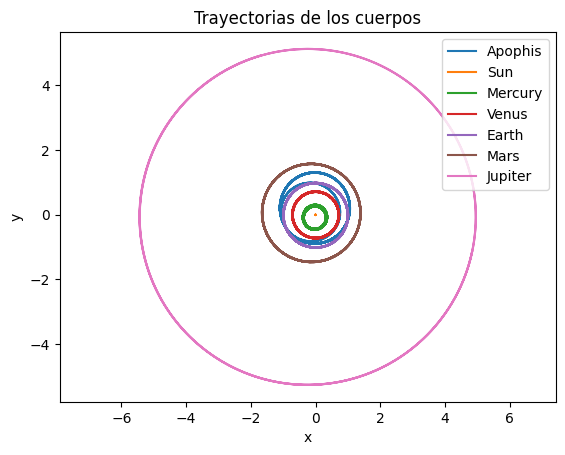

In [34]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Apophis')
plt.plot(rps[1,:,0], rps[1,:,1], label='Sun')
plt.plot(rps[2,:,0], rps[2,:,1], label='Mercury')
plt.plot(rps[3,:,0], rps[3,:,1], label='Venus')
plt.plot(rps[4,:,0], rps[4,:,1], label='Earth')
plt.plot(rps[5,:,0], rps[5,:,1], label='Mars')
plt.plot(rps[6,:,0], rps[6,:,1], label='Jupiter')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

In [35]:
def anima_ncuerpos(masas, rps, T):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulación
    
    # Colores de las partículas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animación sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=f'Cuerpo {j+1}',
            showlegend=False
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()

In [36]:
masas = [sim_solar.particles[i].m for i in range(10)]
anima_ncuerpos(masas, rps, T=100)

# Momento lineal total

In [37]:
suma = 0
for i in range(10):
    suma += sim_solar.particles[i].m*vps[i,0,:]
print(suma)

[4.89426225e-20 3.38813179e-21 3.83811804e-21]


In [38]:
suma_t = 0
for i in range(10):
    suma_t += sim_solar.particles[i].m*vps[i,999,:]
print(suma_t)

[ 5.08219768e-21 -1.01643954e-20  2.64697796e-23]


# Momento angular total

In [39]:
suma = 0
for i in range(10):
    suma += sim_solar.particles[i].m * np.cross(rps[i,0,:], vps[i,0,:])
print(suma)

[9.28461081e-05 2.94210590e-05 3.53433096e-03]


In [40]:
sumat_t = 0
for i in range(10):
  sumat_t += sim_solar.particles[i].m * np.cross(rps[i,999,:], vps[i,999,:])
print(sumat_t)

[9.28461081e-05 2.94210590e-05 3.53433096e-03]


# Energía cineticas y potencial

In [41]:
K = 0
for i in range(10):
    K += 0.5 * sim_solar.particles[i].m * (vps[i,999,0]**2 + vps[i,999,1]**2 + vps[i,999,2]**2)
print(K)

0.0001214715393105325


In [42]:
G = 1
U = 0
for i in range(10):
    for j in range(i + 1, 10):
        rij = np.linalg.norm(rps[i,999,:] - rps[j,999,:])
        U += -G * sim_solar.particles[i].m * sim_solar.particles[j].m / rij
print(U)

-0.00023375443954638163


In [43]:
E = K + U
print(E)

-0.00011228290023584913


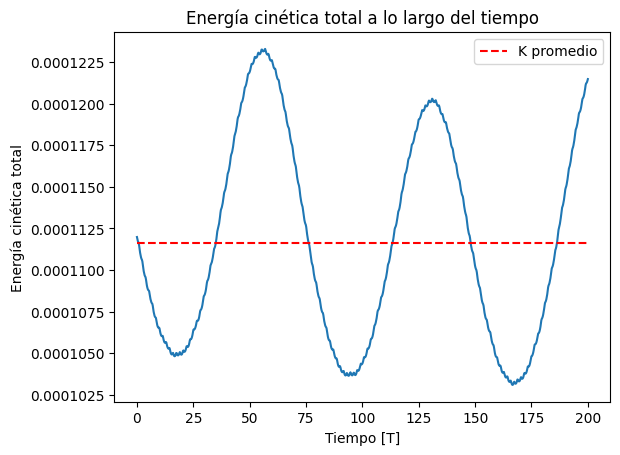

In [44]:
K_t = np.zeros(1000)
for i in range(1000):
    for j in range(10):
        K_t[i] += 0.5 * sim_solar.particles[j].m * (vps[j,i,0]**2 + vps[j,i,1]**2 + vps[j,i,2]**2)

plt.plot(ts, K_t)
plt.hlines(np.mean(K_t), xmin=ts[0], xmax=ts[-1], colors='r', linestyles='dashed', label='K promedio')
plt.xlabel('Tiempo [T]')
plt.ylabel('Energía cinética total')
plt.legend()
plt.title('Energía cinética total a lo largo del tiempo')
plt.show() 

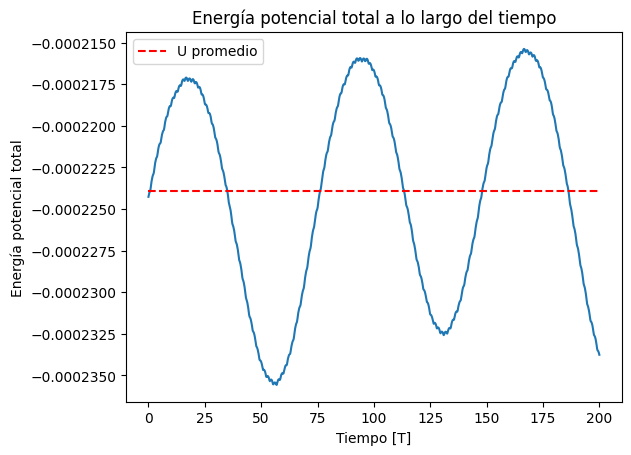

In [45]:
U_t = np.zeros(1000)
for i in range(1000):
    for j in range(10):
        for k in range(j + 1, 10):
            rij = np.linalg.norm(rps[j,i,:] - rps[k,i,:])
            U_t[i] += -G * sim_solar.particles[j].m * sim_solar.particles[k].m / rij

plt.plot(ts, U_t)
plt.hlines(np.mean(U_t), xmin=ts[0], xmax=ts[-1], colors='r', linestyles='dashed', label='U promedio')
plt.xlabel('Tiempo [T]')
plt.ylabel('Energía potencial total')
plt.legend()
plt.title('Energía potencial total a lo largo del tiempo')
plt.show() 

Text(0.5, 1.0, 'Energía total a lo largo del tiempo')

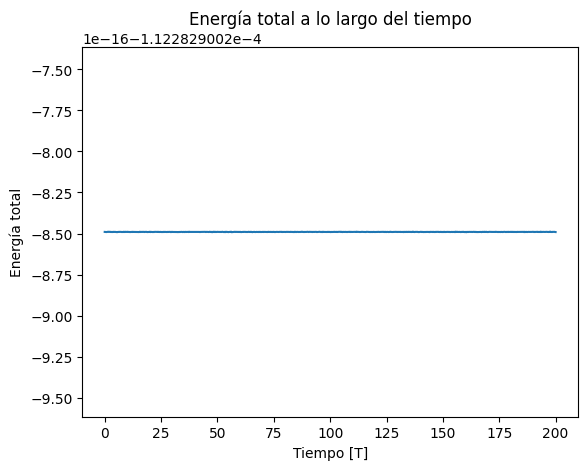

In [46]:
E_t = K_t + U_t
plt.plot(ts, E_t)
plt.xlabel('Tiempo [T]')
plt.ylabel('Energía total')
plt.title('Energía total a lo largo del tiempo')

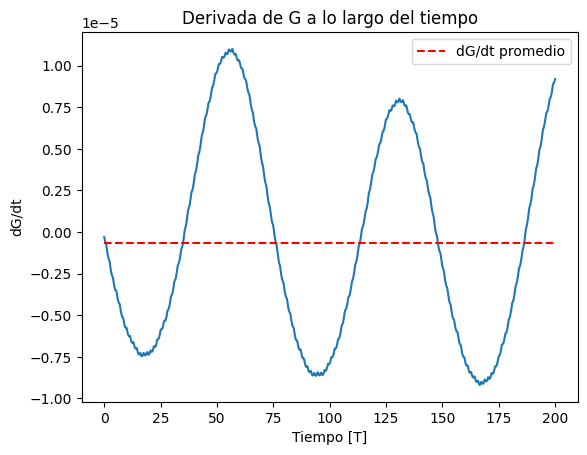

In [47]:
dG_dt = 2 * K_t + U_t
plt.plot(ts, dG_dt)
plt.hlines(np.mean(dG_dt), xmin=ts[0], xmax=ts[-1], colors='r', linestyles='dashed', label='dG/dt promedio')
plt.xlabel('Tiempo [T]')
plt.ylabel('dG/dt')
plt.title('Derivada de G a lo largo del tiempo')
plt.legend()
plt.show()

In [48]:
# Asymptotic means over the final 20% of the simulation
G = 1.0
N = 10
Nt = rps.shape[1]

m = np.array([sim_solar.particles[i].m for i in range(N)])

# K(t) = 1/2 * sum_i m_i * |v_i(t)|^2
K_t = 0.5 * np.sum(m[:, None] * np.sum(vps**2, axis=2), axis=0)

# U(t) = -G * sum_{i<j} m_i m_j / r_ij(t)
U_t = np.zeros(Nt)
for k in range(Nt):
    Uk = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(rps[i, k, :] - rps[j, k, :])
            Uk += -G * m[i] * m[j] / rij
    U_t[k] = Uk

tail_fraction = 0.20
start = int((1.0 - tail_fraction) * Nt)

K_asym = K_t[start:].mean()
U_asym = U_t[start:].mean()
E_asym = (K_t[start:] + U_t[start:]).mean()

print(f'Asymptotic window: last {tail_fraction*100:.0f}% ({Nt-start} samples)')
print(f'<K>_asym = {K_asym:.16e}')
print(f'<U>_asym = {U_asym:.16e}')
print(f'<E>_asym = {E_asym:.16e}')

Asymptotic window: last 20% (200 samples)
<K>_asym = 1.0947157726632423e-04
<U>_asym = -2.2175447750217330e-04
<E>_asym = -1.1228290023584905e-04


In [49]:
G_asym = -2 * K_asym / U_asym
print(f'G_asym = {G_asym:.16e}')

G_asym = 9.8732236209527136e-01


Distancia entre Tierra y apophis

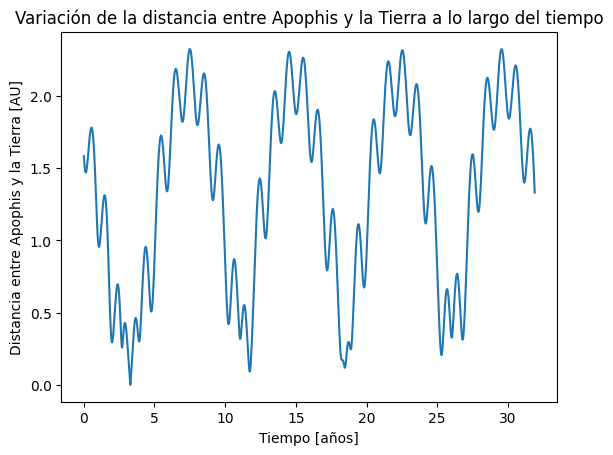

In [50]:
rps_apohis_earth = np.sqrt(np.sum((rps[0,:,:] - rps[4,:,:])**2, axis=1))
T_canon_s = 5033865
seconds_per_year = 365.25 * 24 * 3600
ts_years = ts * T_canon_s / seconds_per_year

plt.plot(ts_years, rps_apohis_earth)
plt.xlabel('Tiempo [años]')
plt.ylabel('Distancia entre Apophis y la Tierra [AU]')
plt.title('Variación de la distancia entre Apophis y la Tierra a lo largo del tiempo')
plt.show()

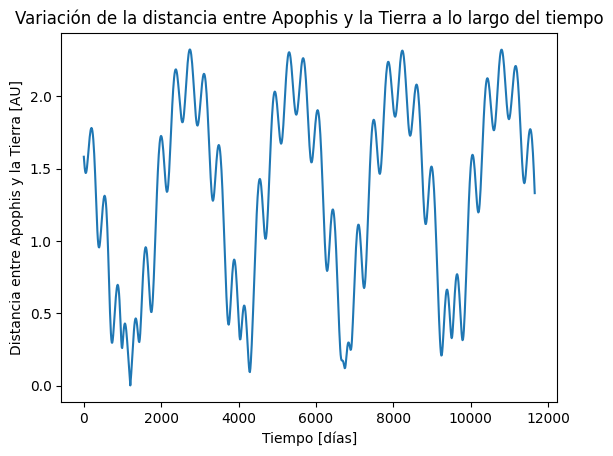

In [51]:
rps_apohis_earth = np.sqrt(np.sum((rps[0,:,:] - rps[4,:,:])**2, axis=1))
T_canon_s = 5033865
seconds_per_day = 24 * 3600
ts_days = ts * T_canon_s / seconds_per_day

plt.plot(ts_days, rps_apohis_earth)
plt.xlabel('Tiempo [días]')
plt.ylabel('Distancia entre Apophis y la Tierra [AU]')
plt.title('Variación de la distancia entre Apophis y la Tierra a lo largo del tiempo')
plt.show()

In [53]:
for i in range(len(rps_apohis_earth)):
    if rps_apohis_earth[i] == rps_apohis_earth.min():
        print(f'La distancia mínima entre Apophis y la Tierra es {rps_apohis_earth[i]:.6f} AU en t = {ts[i]*T_canon_s/seconds_per_day:.2f} días.')

La distancia mínima entre Apophis y la Tierra es 0.000754 AU en t = 1201.41 días.
